# Retrieve Info of Trajectory

In [1]:
# Import Standard Python Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import re
# Import pyLM Libraries
from pyLM import *
from pyLM.units import *
from pySTDLM import *
from pySTDLM import PostProcessing
import csv

Here we define some parameters to decide if saving data in csv or domonstrate visualizatino

In [2]:
if_save_csv = True
if_show_visualization = False
if_compare =True

This is to compare the species across different files

In [5]:
# file_path = "output/24052024/gal_cme_ode_gae2_gia0_rep50_delta1.lm"
# file_path = "output/21082024/gal_cme_ode_gae2_gia0_rep100_delta1.lm"
# output_path = "output/21082024"
# file_name = "gal_cme_ode_gae2_gia0_rep100_delta1.lm"
output_path = "output/12312024"
file_name = "gal_cme_ode_gae_nonregq=1,fmut=0.06_5.55_gia0_rep20_delta1_time420.lm"
file_path = output_path + "/" + file_name 

if 'nonreg' in file_name:
    non_reg_mark = 'noreg'
else:
    non_reg_mark = ''
# Load the data handle

traj = PostProcessing.openLMFile(file_path)

species_list = PostProcessing.getSpecies(traj)
# print(len(species_list))
# print(species_list)
reps = file_path.split('rep')[1].split('_')[0]
# gae = file_path.split('gae')[1].split('_gia')[0].replace('q=40,fmut=0.004_', '').replace('_nonreg', '')
gae_match = re.search(r'fmut=[\d.]+_(\d+\.?\d*)', file_name)
if gae_match:
    gae = gae_match.group(1)
else:
    print("Could not extract GAE value from filename")
    gae = "unknown"
print(f"Extracted GAE value: {gae}", 'mM')
print(f"Extracted reps value: {reps}")

# Reorganize the species list based on the given criteria
species_list = sorted(species_list, key=lambda x: (not x[0].startswith('DG'), not (x[0].startswith('R') or x[0] == 'reporter_rna'), not (x[0].startswith('G') and not x[0].startswith('GA')or x[0] == 'reporter'), x[0].startswith('GA')))
GA_species_list = ['GAI']
general_species_list = [species for species in species_list if species not in GA_species_list]

print(general_species_list)
print(GA_species_list)
print(len(GA_species_list)+ len(general_species_list))
avg_list_general = []
var_list_general = []
time_list_general = []

avg_list_GA = []
var_list_GA = []
time_list_GA = []

for species in general_species_list:
    avg, var, times = PostProcessing.getAvgVarTrace(traj, species)
    avg_list_general.append(avg)
    var_list_general.append(np.sqrt(var))
    time_list_general.append(times)

if len(GA_species_list) == 1:
    species = GA_species_list[0]
    avg, var, times = PostProcessing.getAvgVarTrace(traj, species)
    count2concentration = 4.65e-8  #molecule/cell to mM
    avg_list_GA.append(avg*count2concentration)
    var_list_GA.append(np.sqrt(var)*count2concentration)
    time_list_GA.append(times)
else:
    for species in GA_species_list:
        avg, var, times = PostProcessing.getAvgVarTrace(traj, species)
        count2concentration = 4.65e-8  #molecule/cell to mM
        avg_list_GA.append(avg*count2concentration)
        var_list_GA.append(np.sqrt(var)*count2concentration)
        time_list_GA.append(times)
        
        

# Create a dictionary to store data for each species
species_data = {}
for species, avg, std, times in zip(general_species_list + GA_species_list, 
                                    avg_list_general + avg_list_GA, 
                                    var_list_general + var_list_GA, 
                                    time_list_general + time_list_GA):
    species_name = species if isinstance(species, list) else species
    species_data[species_name] = {'avg': avg, 'std': std, 'times': times}
    
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('/data2/2024_Yeast_GS/my_current_code/rdme_ode')
from matplotlib_pub_figure import setup_publication_style

# Apply the same publication style as figure_multiconc.py
pub_colors = setup_publication_style(figure_size='medium', dpi=300)

if if_show_visualization:
    # Define the genes and their states
    genes = [['DG1', 'DGrep'], ['DG2'], ['DG3', 'DG80']]
    states = ['', '_G4d', '_G4d_G80d']

    # Create a figure with subplots for each gene
    fig, axs = plt.subplots(3, 2, figsize=(20, 10), sharex=True)
    fig.suptitle('Duration of Genes in Different States', fontsize=16, y=0.95)

    # Colors for different states
    colors = ['#B0BEC5', '#4CAF50', '#1E88E5']

    # Create a list to store legend handles
    legend_handles = []

    for row, gene_row in enumerate(genes):
        for col, gene in enumerate(gene_row):
            ax = axs[row, col]
            bottom = np.zeros_like(times)
            
            for j, state in enumerate(states):
                species_name = f'{gene}{state}'
                if species_name in species_data:
                    values = species_data[species_name]['avg']
                    handle = ax.fill_between(times, bottom, bottom + values, alpha=0.7, color=colors[j])
                    bottom += values
                    
                    # Only add to legend_handles for the first gene (to avoid duplicates)
                    if row == 0 and col == 0 and j == 0:
                        legend_handles = [handle]
                    elif row == 0 and col == 0:
                        legend_handles.append(handle)
            
            ax.set_ylabel('Probability')
            # No grid to match figure_multiconc.py style
            ax.grid(False)

        # Hide unused subplot
        if len(gene_row) == 1:
            axs[row, 1].set_visible(False)

    # Set x-label for bottom subplots
    for ax in axs[-1, :]:
        ax.set_xlabel('Time (min)')

    # Add a single legend for all subplots
    fig.legend(legend_handles, ['Free', 'Activated', 'Repressed'], 
            loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)

    # Add the file_name as a string in the bottom right of the figure
    plt.gcf().text(0.95, 0.01, file_name, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, top=0.92)  # Adjust these values to make room for the title and legend
    plt.show()

    # Save the figure
    fig.savefig(output_path + f'/gene_states_duration_{file_name}.png', dpi=600, bbox_inches='tight')

# show in order of species_list
if if_show_visualization:
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Define the desired order of species
    species_order = [
        ['G1', 'G1GAI', 'G1+G1GAI', 'reporter'],
        ['G2', 'G2GAE', 'G2GAI', 'G2+G2GAE+G2GAI'],
        ['G3', 'G3i','G80G3i'],
        ['G4', 'G4d', 'G80','G80C', 'G80d','G80Cd' ],
        ['GAI','GAI+G3i']
    ]

    # Check if names in species_order are in species_data, if not, create sum species_data
    for row in species_order:
        for species_name in row:
            if species_name not in species_data:
                if '+' in species_name:
                    sub_species = species_name.split('+')
                    # print(sub_species)
                    if all(sub in species_data for sub in sub_species):
                        avg_sum = np.sum([species_data[sub]['avg'] for sub in sub_species], axis=0)
                        std_sum = np.sqrt(np.sum([species_data[sub]['std']**2 for sub in sub_species], axis=0))
                        times = species_data[sub_species]['times']
                        species_data[species_name] = {'avg': avg_sum, 'std': std_sum, 'times': times}
                else:
                    print(f"{species_name} not in species_data, please check")
    # Prepare plot layout
    nrows = len(species_order)
    ncols = max(len(row) for row in species_order)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))

    # Plot data in the specified order - using same color scheme as figure_multiconc.py
    for row, species_row in enumerate(species_order):
        for col, species_name in enumerate(species_row):
            ax = axs[row, col]
            if species_name in species_data:
                data = species_data[species_name]
            
                # Use the first color from the Nature palette for consistency
                color = '#0072B2'  # Blue color from Nature palette
                ax.plot(data['times'], data['avg'], c=color)
            
                ax.fill_between(data['times'], data['avg'] - data['std'], data['avg'] + data['std'], 
                                color=color, alpha=0.3)
                
                if species_name == 'GAI':
                    ax.axhline(y=float(gae), color='r', linestyle='--')
                    ax.set(ylabel='Concentration (mM)')
                elif species_name.startswith('DG'):  # Change y-label for species starting with 'DG'
                    ax.set_ylabel('Probability')
                else:
                    ax.set(ylabel='Count')
                
                ax.set(title=species_name, xlabel='Time (min)', 
                    xticks=np.arange(0, max(data['times']), 120))
                
                # No grid to match figure_multiconc.py style
                ax.grid(False)
            else:
                ax.set_visible(False)

        # Hide unused subplots in this row
        for col in range(len(species_row), ncols):
            axs[row, col].set_visible(False)

    # Adjust layout and add title
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.suptitle(f"Species Trajectories - GAE: {gae}mM, Reps: {reps}", fontsize=16)

    # Add a single legend at the bottom
    fig.legend(labels=["Average", "Std Dev"], loc='lower center', ncol=2, fontsize=10)

    # Add the file_name as a string in the bottom right of the figure
    plt.gcf().text(0.95, 0.01, file_name, fontsize=10, verticalalignment='bottom', horizontalalignment='right')

    # Save the figure
    plt.savefig(output_path + f'/ordered_species_trajectories_{file_name}.png', dpi=600, bbox_inches='tight')
    plt.show()

Extracted GAE value: 5.55 mM
Extracted reps value: 20
['R1', 'R2', 'R3', 'R4', 'R80', 'G1', 'G2', 'G3', 'G3i', 'G4', 'G4d', 'G80', 'G80C', 'G80d', 'G80Cd', 'G80G3i', 'G2GAI', 'G2GAE', 'G1GAI', 'reporter_rna', 'reporter', 'DG1', 'DG1_G4d', 'DG1_G4d_G80d', 'DG2', 'DG2_G4d', 'DG2_G4d_G80d', 'DG3', 'DGrep', 'DGrep_G4d', 'DGrep_G4d_G80d', 'DG80']
['GAI']
33


unique_gae_values: [0.0, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 16.0, 20.0]
Extracting data from: gal_cme_ode_gae10mM_10_gia0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae4mM_4_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae2mM_2_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae8mM_8_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae16mM_16_gia0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae1mM_1_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae20mM_20_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae6mM_6_gai0_rep20_delta1_time60.lm
Extracting data from: gal_cme_ode_gae0mM_0_gai0_rep20_delta1_time60.lm
Saving plots to: output/03222025/compare/comparison_plots
Created comparison plot for R1
Created comparison plot for R2
Created comparison plot for R3
Created comparison plot for R4
Created comparison plot for R80
Created comparison plot for G1
Created comparison plot for G2
Created com

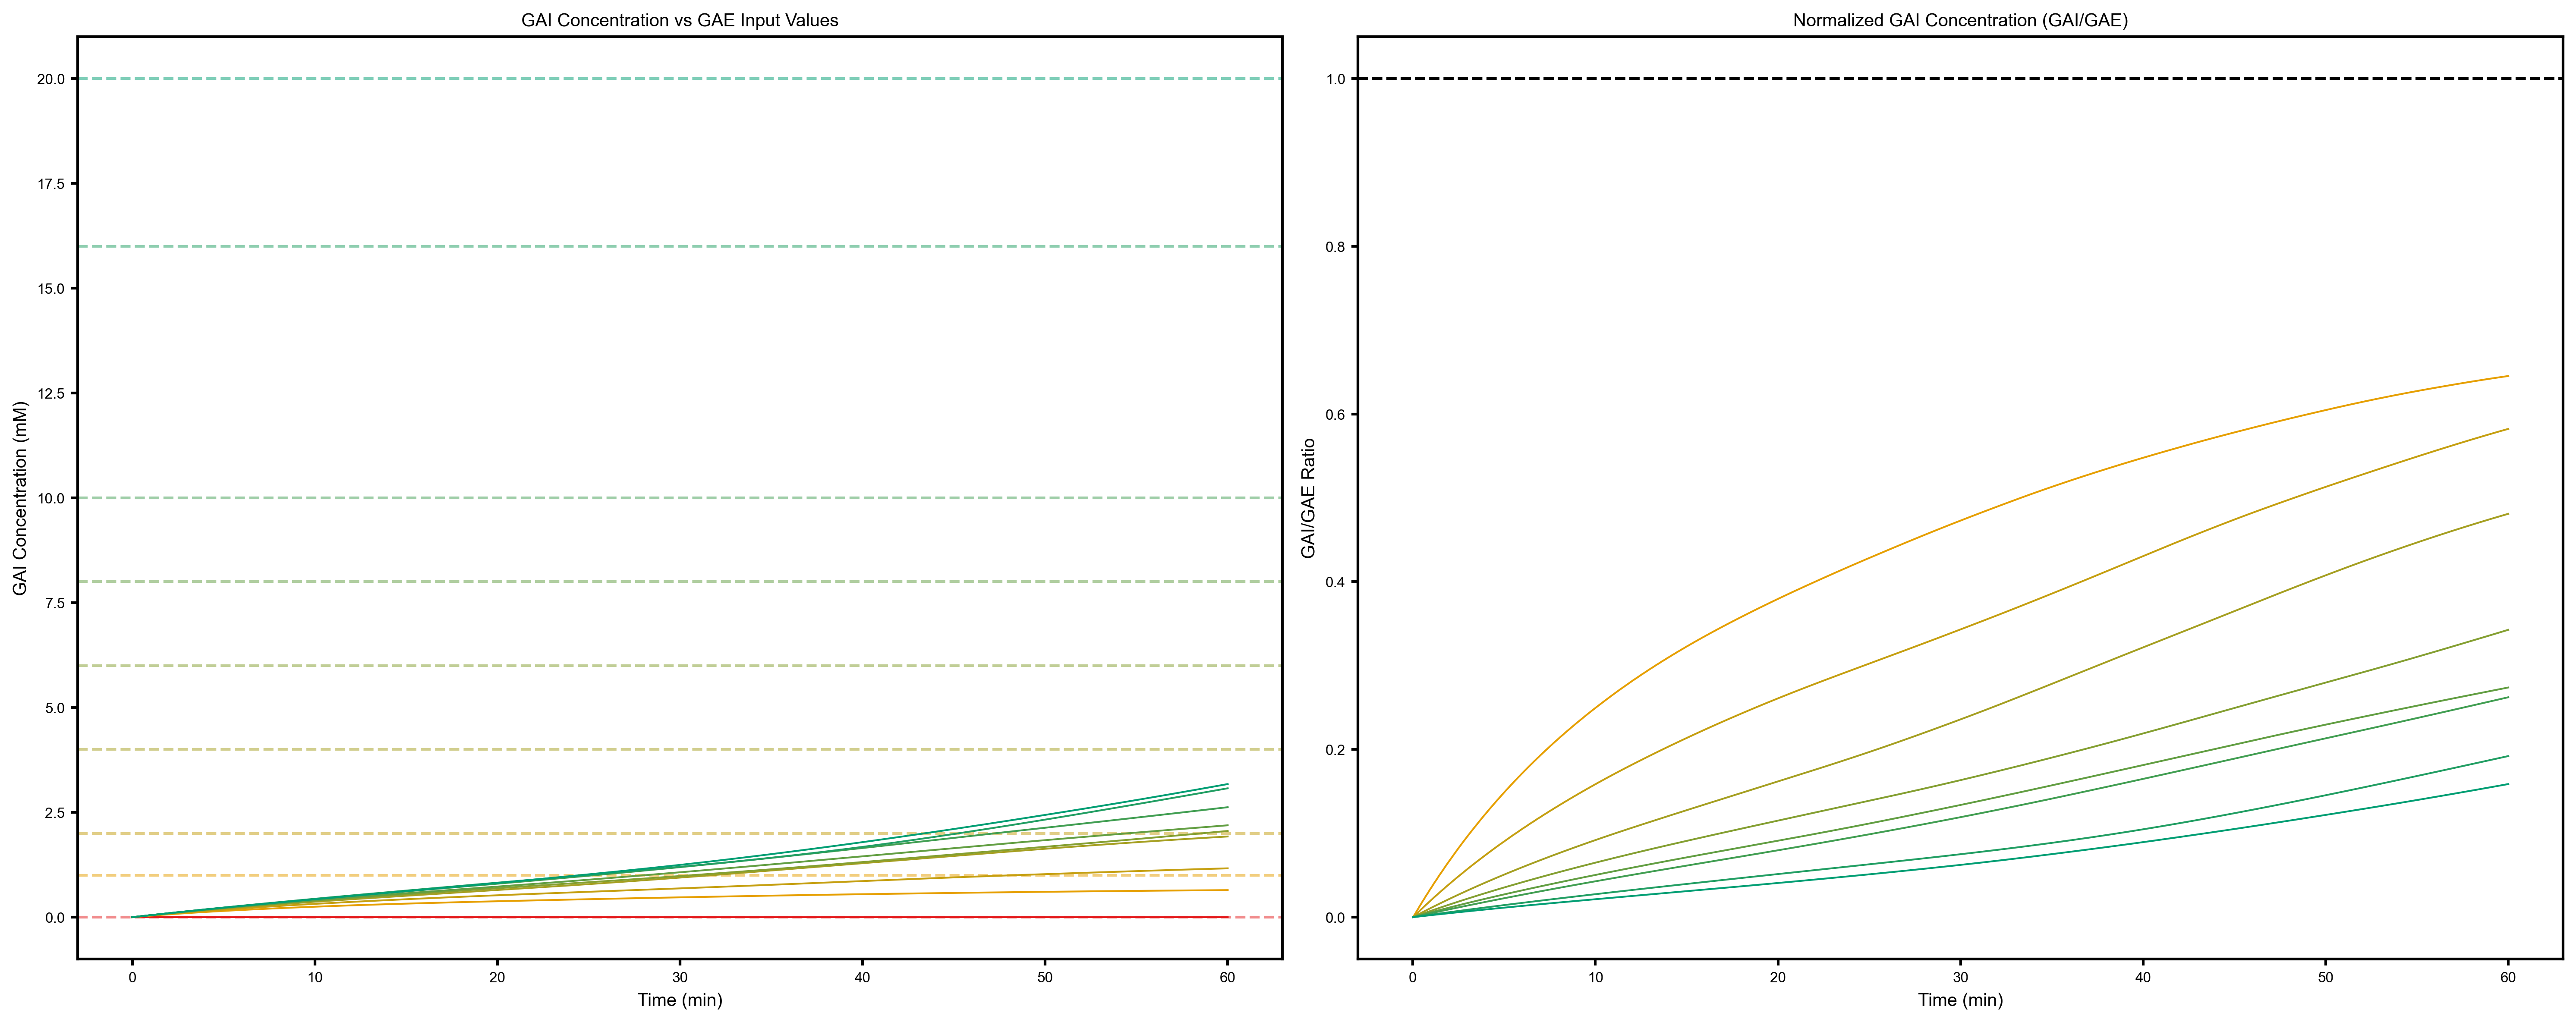

In [9]:
def plot_species_comparison_across_files(output_path, species_to_plot=None, save_dir=None, show_variance=False, combined_species=None):
    """
    Create comparative plots for each species across all .lm files.
    
    Parameters:
    -----------
    output_path : str
        Path to the directory containing .lm files
    species_to_plot : list, optional
        List of species names to plot. If None, will use all available species.
    save_dir : str, optional
        Directory to save the plots. If None, will use output_path.
    """
    import os
    import glob
    import re
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib_pub_figure import setup_publication_style
    
    # Apply the same publication style as figure_multiconc.py
    pub_colors = setup_publication_style(figure_size='medium', dpi=300)

    # Set default for combined_species if not provided
    if combined_species is None:
        combined_species = {}
    # Set save directory - use output_path if save_dir is not specified
    if save_dir is None:
        save_dir = output_path
    
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Get all .lm files in the output directory
    lm_files = glob.glob(os.path.join(output_path, "*.lm"))
    
    if len(lm_files) == 0:
        print(f"No .lm files found in {output_path}")
        return
    
    # Dictionary to store data for each file and species
    all_data = {}
    all_available_species = set()
    
    # Extract GAE values first to determine color mapping
    gae_values = []
    for file_path in lm_files:
        file_name = os.path.basename(file_path)
        gae_match = re.search(r'gae(\d+)mM_(\d+\.?\d*)', file_name)
        if gae_match:
            gae_prefix = gae_match.group(1)
            gae_suffix = gae_match.group(2)
            gae = f"{gae_prefix}.{gae_suffix}" if '.' not in gae_suffix else gae_suffix
        else:
            old_pattern_match = re.search(r'fmut=[\d.]+_(\d+\.?\d*)', file_name)
            if old_pattern_match:
                gae = old_pattern_match.group(1)
            else:
                gae = "0"  # Default to 0 if unknown
        
        try:
            if '.' in gae:
                gae_values.append(float(gae.split('.')[0]))
            else:
                gae_values.append(float(gae))
        except ValueError:
            gae_values.append(0)  # Default to 0 if conversion fails
    
    
    # Sort unique GAE values to map colors properly
    unique_gae_values = sorted(set(gae_values))
    print(f"unique_gae_values: {unique_gae_values}")
    
    # Use the same Nature journal color palette as in figure_multiconc.py
    nature_colors = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#E69F00', '#F0E442']
    # Blue, Green, Orange-red, Pink, Light blue, Orange, Yellow
    
    # Import matplotlib colors for gradient
    import matplotlib.colors as mcolors
    
    # Create the same colormap from orange to green as in figure_multiconc.py
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "nature_gradient", [nature_colors[5], nature_colors[1]], N=100)

    # Create colors dictionary mapping file index to color - same logic as figure_multiconc.py
    colors = {}
    for i, file_path in enumerate(lm_files):
        file_name = os.path.basename(file_path)
        gae_match = re.search(r'gae(\d+)mM_(\d+\.?\d*)', file_name)
       
        if gae_match:
            gae_prefix = gae_match.group(1)
            gae_suffix = gae_match.group(2)
            gae = f"{gae_prefix}" if '.' not in gae_suffix else gae_suffix
        else:
            old_pattern_match = re.search(r'fmut=[\d.]+_(\d+\.?\d*)', file_name)
            if old_pattern_match:
                gae = old_pattern_match.group(1)
            else:
                gae = "0"  # Default to 0 if unknown
        
        try:
            gae_float = float(gae)
            
            # Special case: use red for GAE=0 (same as figure_multiconc.py)
            if gae_float == 0 or re.search(r'(?<!\d)0mM$', file_name):
                colors[i] = '#E41A1C'  # Red for 0mM
            else:
                # For non-zero GAE values, use a gradient from orange to green
                non_zero_values = sorted([v for v in unique_gae_values if v > 0])
                
                if non_zero_values:
                    position = non_zero_values.index(gae_float)
                    norm_value = position / max(1, len(non_zero_values) - 1)
                    colors[i] = cmap(norm_value)
                else:
                    colors[i] = nature_colors[0]  # Default to blue if no non-zero values
        except ValueError:
            print(f"Error converting GAE value {gae} to float")
            colors[i] = nature_colors[0]  # Default to blue if conversion fails
 
    
    # Process each file to extract data
    for i, file_path in enumerate(lm_files):
        try:
            file_name = os.path.basename(file_path)
            print(f"Extracting data from: {file_name}")
            
            # Extract GAE value from filename
            gae_match = re.search(r'gae(\d+)mM_(\d+\.?\d*)', file_name)
            if gae_match:
                gae_prefix = gae_match.group(1)
                gae_suffix = gae_match.group(2)
                gae = f"{gae_prefix}" if '.' not in gae_suffix else gae_suffix
            else:
                old_pattern_match = re.search(r'fmut=[\d.]+_(\d+\.?\d*)', file_name)
                if old_pattern_match:
                    gae = old_pattern_match.group(1)
                else:
                    gae = "unknown"
            
            # Extract reps value
            reps_match = re.search(r'rep(\d+)', file_name)
            reps = reps_match.group(1) if reps_match else "unknown"
            
            # Load the data
            traj = PostProcessing.openLMFile(file_path)
            species_list = PostProcessing.getSpecies(traj)
            
            # Add all species to the set of available species
            for species in species_list:
                all_available_species.add(species)
            
            # Organize species
            GA_species_list = ['GAI']
            general_species_list = [species for species in species_list if species not in GA_species_list]
            
            # Extract data for all species
            species_data = {}
            
            # Process general species
            for species in general_species_list:
                avg, var, times = PostProcessing.getAvgVarTrace(traj, species)
                species_data[species] = {'avg': avg, 'std': np.sqrt(var), 'times': times}
            
            # Process GA species
            for species in GA_species_list:
                if species in [s for s in species_list]:  # Check if species exists in this file
                    avg, var, times = PostProcessing.getAvgVarTrace(traj, species)
                    count2concentration = 4.65e-8  # molecule/cell to mM
                    species_data[species] = {
                        'avg': avg * count2concentration, 
                        'std': np.sqrt(var) * count2concentration, 
                        'times': times
                    }
            # After processing all individual species, create combined species data
            for combined_name, component_species in combined_species.items():
                # Check if all component species exist in this file
                if all(species in species_data for species in component_species):
                    # Get the times from the first component species (assuming all have same time points)
                    times = species_data[component_species[0]]['times']
                    
                    # Sum the averages and calculate combined standard deviation
                    # (using error propagation for independent variables: sqrt(sum of squares))
                    combined_avg = np.zeros_like(species_data[component_species[0]]['avg'])
                    combined_var = np.zeros_like(species_data[component_species[0]]['std'])
                    
                    for species in component_species:
                        combined_avg += species_data[species]['avg']
                        combined_var += species_data[species]['std']**2
                    
                    combined_std = np.sqrt(combined_var)
                    
                    # Store the combined data
                    species_data[combined_name] = {
                        'avg': combined_avg,
                        'std': combined_std,
                        'times': times,
                        'components': component_species  # Store the components for reference
                    }
            
            # Store in all_data with file info
            all_data[file_name] = {
                'species_data': species_data,
                'gae': gae,
                'reps': reps,
                'color': colors[i]
            }
            
            
        except Exception as e:
            print(f"Error processing file {file_path}: {str(e)}")
            continue
    
    # If no specific species list is provided, use all available species
    if species_to_plot is None:
        species_to_plot = sorted(list(all_available_species))
        print(f"Found {len(species_to_plot)} species to plot: {', '.join(species_to_plot)}")
    
    # Create a comparison directory inside save_dir
    comparison_dir = os.path.join(save_dir, "comparison_plots")
    os.makedirs(comparison_dir, exist_ok=True)
    print(f"Saving plots to: {comparison_dir}")
    
    # Create plots for each species
    for species_name in species_to_plot:
        try:
            # Skip species that don't exist in any file
            if not any(species_name in file_data['species_data'] for file_data in all_data.values()):
                print(f"Species {species_name} not found in any file, skipping.")
                continue
            
            fig, ax = plt.subplots()  # Use default figsize from publication style
            legend_elements = []
            
            # Sort files by GAE value for better visualization
            sorted_files = sorted(all_data.items(), 
                                 key=lambda x: float(x[1]['gae']) if x[1]['gae'] != "unknown" else -1)
            
            for file_name, file_data in sorted_files:
                if species_name in file_data['species_data']:
                    data = file_data['species_data'][species_name]
                    color = file_data['color']
                    
                    # Plot average - no standard deviation fill to match figure_multiconc.py style
                    ax.plot(data['times'], data['avg'], color=color, linewidth=1)
                    
                    # Add to legend
                    legend_elements.append(
                        Line2D([0], [0], color=color, lw=2, 
                               label=f"GAE: {file_data['gae']}mM, Reps: {file_data['reps']}")
                    )
            
            # Set axis labels - same style as figure_multiconc.py
            if species_name == 'GAI':
                ax.set_ylabel('Concentration (mM)')
            elif species_name.startswith('DG'):
                ax.set_ylabel('Probability')
            else:
                ax.set_ylabel('Counts')
            
            ax.set_xlabel('Time (min)')
            # No title to match figure_multiconc.py style
            
            # No grid and no legend to match figure_multiconc.py style
            ax.grid(False)
            
            # Save the figure
            plt.tight_layout()
            plt.savefig(os.path.join(comparison_dir, f'comparison_{species_name}.png'), dpi=600, bbox_inches='tight')
            plt.close(fig)
            
            print(f"Created comparison plot for {species_name}")
            
        except Exception as e:
            print(f"Error creating plot for species {species_name}: {str(e)}")
            continue
    
    # Create a summary plot for GAI with GAE values as horizontal lines
    try:
        if 'GAI' in all_available_species:
            # Create two plots: one for raw values and one for normalized values
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
            legend_elements = []
            
            # Sort files by GAE value
            sorted_files = sorted(all_data.items(), 
                                 key=lambda x: float(x[1]['gae']) if x[1]['gae'] != "unknown" else -1)
            
            # Plot GAI for each file
            for file_name, file_data in sorted_files:
                if 'GAI' in file_data['species_data']:
                    data = file_data['species_data']['GAI']
                    color = file_data['color']
                    gae_value = float(file_data['gae']) if file_data['gae'] != "unknown" else 0
                    
                    # Plot 1: Raw values
                    ax1.plot(data['times'], data['avg'], color=color, linewidth=1)
                    
                    # Add horizontal line for GAE value
                    ax1.axhline(y=gae_value, color=color, linestyle='--', alpha=0.5)
                    
                    # Plot 2: Normalized values (GAI/GAE)
                    if gae_value > 0:  # Avoid division by zero
                        normalized_avg = data['avg'] / gae_value
                        
                        ax2.plot(data['times'], normalized_avg, color=color, linewidth=1)
                        
                        # Add horizontal line at 1.0 (perfect conversion)
                        ax2.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
                    
                    # Add to legend
                    legend_elements.append(
                        Line2D([0], [0], color=color, lw=2, 
                               label=f"GAE: {file_data['gae']}mM, Reps: {file_data['reps']}")
                    )
            
            # Set axis labels - same style as figure_multiconc.py
            ax1.set_ylabel('GAI Concentration (mM)')
            ax1.set_xlabel('Time (min)')
            ax1.set_title('GAI Concentration vs GAE Input Values')
            
            ax2.set_ylabel('GAI/GAE Ratio')
            ax2.set_xlabel('Time (min)')
            ax2.set_title('Normalized GAI Concentration (GAI/GAE)')
            
            # No grid to match figure_multiconc.py style
            ax1.grid(False)
            ax2.grid(False)
            
            # Save the figure
            plt.tight_layout()
            plt.savefig(os.path.join(comparison_dir, 'GAI_vs_GAE_comparison.png'),  bbox_inches='tight')
            
            # Create a separate plot just for the normalized values
            fig, ax = plt.subplots()
            
            for file_name, file_data in sorted_files:
                if 'GAI' in file_data['species_data']:
                    data = file_data['species_data']['GAI']
                    color = file_data['color']
                    gae_value = float(file_data['gae']) if file_data['gae'] != "unknown" else 0
                    
                    if gae_value > 0:  # Avoid division by zero
                        normalized_avg = data['avg'] / gae_value
                        ax.plot(data['times'], normalized_avg, color=color)
            
            # Add horizontal line at 1.0 (perfect conversion)
            ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='GAE reference')
            ax.text(data['times'][0]*1.05, 1*0.97, 'External GAE', color='gray', va='top', ha='left')
            
            ax.set_ylabel('GAI/GAE ratio')
            ax.set_xlabel('Time (min)')
            # No title to match figure_multiconc.py style
            ax.grid(False)
            
            plt.tight_layout()
            plt.savefig(os.path.join(comparison_dir, 'GAI_normalized_by_GAE.png'), dpi=600, bbox_inches='tight')
            plt.close(fig)
            
            print("Created GAI vs GAE comparison plots with normalization")
    except Exception as e:
        print(f"Error creating GAI vs GAE plot: {str(e)}")
        
    # Create a separate legend figure - same style as figure_multiconc.py
    def create_legend_figure(labels, colors, fig_dir):
        plt.figure(figsize=(10, 3))
        ax = plt.gca()
        
        # Calculate how many items per row
        items_per_row = int(np.ceil(len(labels) / 2))
        
        # Create proxy artists for the legend
        first_row = []
        for i in range(min(items_per_row, len(labels))):
            line = plt.Line2D([0], [0], color=colors[i], lw=2)
            first_row.append((line, labels[i]))
        
        # Second row if needed
        second_row = []
        for i in range(items_per_row, len(labels)):
            line = plt.Line2D([0], [0], color=colors[i], lw=2)
            second_row.append((line, labels[i]))
        
        # Create the first legend for the first row
        if first_row:
            first_legend = ax.legend(*zip(*first_row), loc='upper center', 
                                   bbox_to_anchor=(0.5, 0.8), ncol=items_per_row, framealpha=0.3)
            plt.gca().add_artist(first_legend)
        
        # Create the second legend for the second row
        if second_row:
            second_legend = ax.legend(*zip(*second_row), loc='upper center', 
                                    bbox_to_anchor=(0.5, 0.2), ncol=len(second_row), framealpha=0.3)
        
        # Hide axis
        ax.set_axis_off()
        
        # Save the legend figure
        plt.tight_layout()
        legend_path = os.path.join(fig_dir, 'legend.png')
        plt.savefig(legend_path, dpi=600, bbox_inches='tight', transparent=True)
        plt.close()
        
        return legend_path
    
    # Extract labels and colors for legend
    legend_labels = [f"GAE: {file_data[1]['gae']}mM, Reps: {file_data[1]['reps']}" for file_data in sorted_files]
    legend_colors = [file_data[1]['color'] for file_data in sorted_files]

    create_legend_figure(legend_labels, legend_colors, comparison_dir)
    
    print("Created separate legend figure")
    print("Completed creating comparison plots")

if_compare = True
# Example usage:
if if_compare:
    plot_species_comparison_across_files("output/03222025/", species_to_plot=['R1', 'R2', 'R3', 'R4', 'R80', 'G1', 'G2', 'G3', 'G3i', 'G4', 'G4d', 'G80', 'G80C', 'G80d', 'G80Cd', 'G80G3i', 'GAI', 'G2GAI', 'G2GAE', 'G1GAI', 'reporter_rna', 'reporter', 'DG1', 'DG1_G4d', 'DG1_G4d_G80d', 'DG2', 'DG2_G4d', 'DG2_G4d_G80d', 'DG3', 'DG3_G4d', 'DG3_G4d_G80d', 'DGrep', 'DGrep_G4d', 'DGrep_G4d_G80d', 'DG80', 'DG80_G4d', 'DG80_G4d_G80d', 'GAI',  'G2_total'], save_dir='output/03222025/compare/',
    combined_species={'G2_total': ['G2', 'G2GAI', 'G2GAE']})
# Or with custom species list:
# plot_species_comparison_across_files("output/03222025", ['G1', 'G2', 'GAI'])

## Info Extraction

In [ ]:
break

SyntaxError: 'break' outside loop (668683560.py, line 4)

the following code is depreciated, it is to show all species in the order of species_list

## G2 related trajectory

In [ ]:
# Find the index of G2 in the species list
g2_index = species_list.index(['G2'])

# Extract G2 data
g2_avg = avg_list_general[g2_index]
g2_std = var_list_general[g2_index]
g2_times = time_list_general[g2_index]

# Create the plot using the same publication style
fig, ax = plt.subplots()
ax.plot(g2_times, g2_avg, color='#0072B2')  # Use Nature journal blue color
ax.fill_between(g2_times, g2_avg - g2_std, g2_avg + g2_std, alpha=0.3, color='#0072B2')

ax.set_xlabel('Time (min)')
ax.set_ylabel('G2 Count')
# No title to match figure_multiconc.py style
ax.set_ylim(0, 3600)  # Set y-axis limits to 0-3600
# No legend since it's a single species
ax.grid(False)  # No grid to match figure_multiconc.py style

# Save the figure
plt.tight_layout()
plt.savefig(f'{output_path}/avgg2_gal_cme_ode_gae{gae}_gia0_rep{reps}_delta0.5.png', dpi=600, bbox_inches='tight')
plt.show()

## Number of G2 distribution in 700 min

In [ ]:
# This needs to be modified when processing different data
file_path = "output/22082024/gal_cme_ode_gae0.055_gia0_rep500_delta1.lm"
reps = 500

# here we start to draw the distribution of G2 at 700 min
times = PostProcessing.getTimesteps(file_path)
g2_rep1 =PostProcessing.getSpecieTrace(file_path,specie='G2',replicate=1)
import scipy.stats as stats

# Find the index closest to time = 700
target_time = 700
closest_index = min(range(len(times)), key=lambda i: abs(times[i] - target_time))

# Initialize a list to store G2 values at t=700 for all replicates
g2_values_at_700 = []

# Loop through all replicates
for rep in range(1, reps + 1):
    g2_trace = PostProcessing.getSpecieTrace(file_path, specie='G2', replicate=rep)
    g2_values_at_700.append(g2_trace[closest_index])

# Create a kernel density estimation
kde = stats.gaussian_kde(g2_values_at_700)

# Create points on which to evaluate the distribution
x_range = np.linspace(min(g2_values_at_700), max(g2_values_at_700), 100)

# Print some statistics
# Calculate statistics
mean_g2 = np.mean(g2_values_at_700)
median_g2 = np.median(g2_values_at_700)
std_g2 = np.std(g2_values_at_700)

# Plot the continuous distribution using the same publication style
fig, ax = plt.subplots()
ax.plot(x_range, kde(x_range), color='#0072B2')  # Use Nature journal blue color
ax.set_xlabel('G2 Count')
ax.set_ylabel('Density')
# No title to match figure_multiconc.py style
ax.grid(False)  # No grid to match figure_multiconc.py style

# Add statistics to the plot
ax.text(0.05, 0.95, f"Mean: {mean_g2:.2f}\nMedian: {median_g2:.2f}\nStd Dev: {std_g2:.2f}", 
         transform=ax.transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{output_path}/G2_distribution_t{times[closest_index]:.0f}.png', dpi=600, bbox_inches='tight')
plt.show()

# Print statistics
print(f"Mean G2 count at t={times[closest_index]:.2f}: {mean_g2:.2f}")
print(f"Median G2 count at t={times[closest_index]:.2f}: {median_g2:.2f}")
print(f"Standard deviation of G2 count at t={times[closest_index]:.2f}: {std_g2:.2f}")

## G2 family

In [ ]:
# Create a figure and axis using the same publication style
fig, ax = plt.subplots()

# Limit the time steps to the first 120
time_limit = g2_times[:61]
g2_avg_limit = g2_avg[:61]
g2gai_avg_limit = g2gai_avg[:61]
g2gae_avg_limit = g2gae_avg[:61]

# Calculate final counts
final_count = g2_avg_limit + g2gai_avg_limit + g2gae_avg_limit

# Use Nature journal colors for stacking
# Plot the filled area for G2GAE first
ax.fill_between(time_limit, g2_avg_limit + g2gai_avg_limit, g2_avg_limit + g2gai_avg_limit + g2gae_avg_limit, 
                color='#E69F00', alpha=0.5, label='G2GAE in ODE')  # Orange

# Then plot G2GAI
ax.fill_between(time_limit, g2_avg_limit, g2_avg_limit + g2gai_avg_limit, 
                color='#D55E00', alpha=0.5, label='G2GAI in ODE')  # Orange-red

# Finally, plot G2 in ODE
ax.fill_between(time_limit, 0, g2_avg_limit, 
                color='#0072B2', alpha=0.5, label='G2 in ODE')  # Blue

# Add final count to the plot
plt.gcf().text(0.95, 0.65, f'Final Count: {int(final_count[-1])}' ,
               verticalalignment='bottom', horizontalalignment='left', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Customize the plot to match figure_multiconc.py style
ax.set_xlabel('Time (min)')
ax.set_ylabel('Counts')
# No title to match figure_multiconc.py style
ax.grid(False)  # No grid to match figure_multiconc.py style
# No legend to match figure_multiconc.py style

# Save and show the plot
plt.tight_layout()
plt.savefig(f'{output_path}/G2_family_stacked.png', dpi=600, bbox_inches='tight')
plt.show()